## — Exploración preliminar (borrador, no forma parte de la entrega)

**Objetivo:** ejecutar `eda()` de forma completa, sin exclusiones, sobre las 
39 columnas del dataset, para tener un primer vistazo de todo antes de decidir 
qué columnas excluir en el EDA oficial (`03_eda.ipynb`).

**Importante:** este notebook es un borrador de trabajo, no un entregable. 
No se comenta cada gráfico ni cada columna — su única función es servir de 
base para decidir `cols_excluir`, que luego se documenta y justifica en 
`03_eda.ipynb`.

Como incluye columnas identificadoras (`id_cliente`, `product_id`) con miles 
de valores únicos, el output de esta celda es intencionadamente largo — es 
el motivo por el que esta exploración se mantiene separada del notebook final.

In [1]:
# Libreria de Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Exploracion de Archivos de soporte
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se
from src import sp_abtest as sa

# # Librerías estadísticas (uso indirecto: llamadas ya encapsuladas en sp_abtest.py,
# se deja el import como recordatorio de qué hay por debajo del soporte)
import scipy.stats as stats

# Para que se muestren todas las columnas al imspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


### Carga de datos

In [2]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)
df.shape

(52000, 39)

In [6]:
df_pedidos = df

### Exploración completa con `eda()`, sin exclusiones

Genera estadísticas, countplots, histogramas y boxplots de las 39 columnas 
de golpe. El output de "Valores únicos" para `id_cliente` y `product_id` 
será muy largo (miles de líneas) — es esperado, no es un error.

VARIABLES NUMERICAS:

 Index(['order_id', 'cantidad', 'precio_unitario', 'descuento', 'importe_total',
       'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista',
       'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad',
       'ingresos_anuales', 'latitude', 'longitude', 'visitas_web_mes',
       'precio_unitario_wz', 'importe_total_wz'],
      dtype='str')

VARIABLES CATEGORICAS:

 Index(['id_cliente', 'product_id', 'metodo_pago', 'envio_gratis', 'devuelto',
       'canal', 'categoria_producto', 'nombre_producto', 'marca', 'proveedor',
       'estado_civil', 'nivel_educativo', 'tiene_hijos',
       'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'],
      dtype='str')

VARIABLES DATETIME(FECHA):

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

VARIABLES NUMERICAS:
                            count      mean       std       min       25%       50%       75%        max
orde

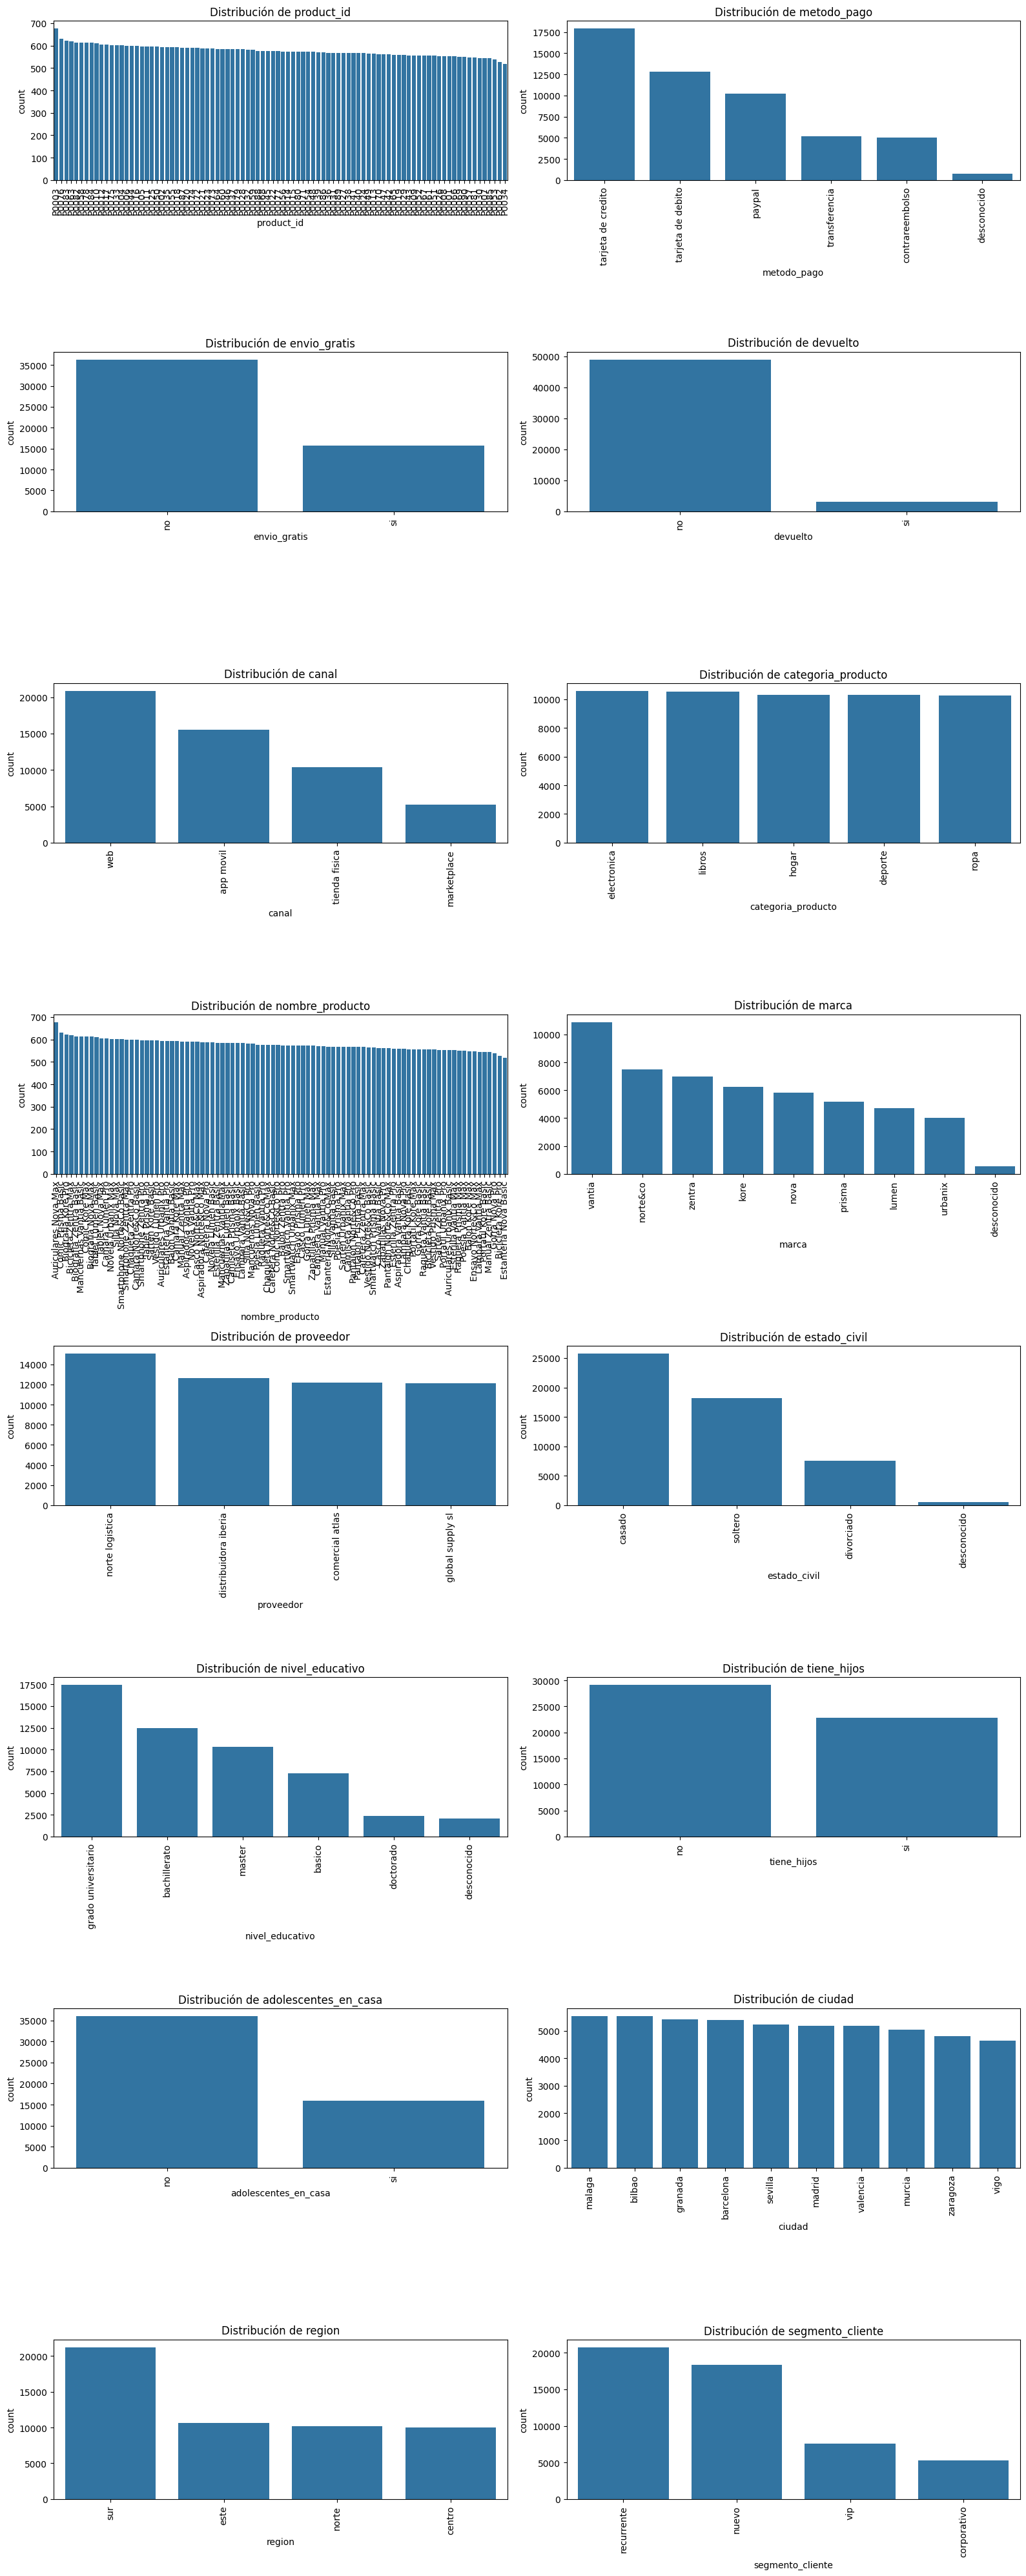


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


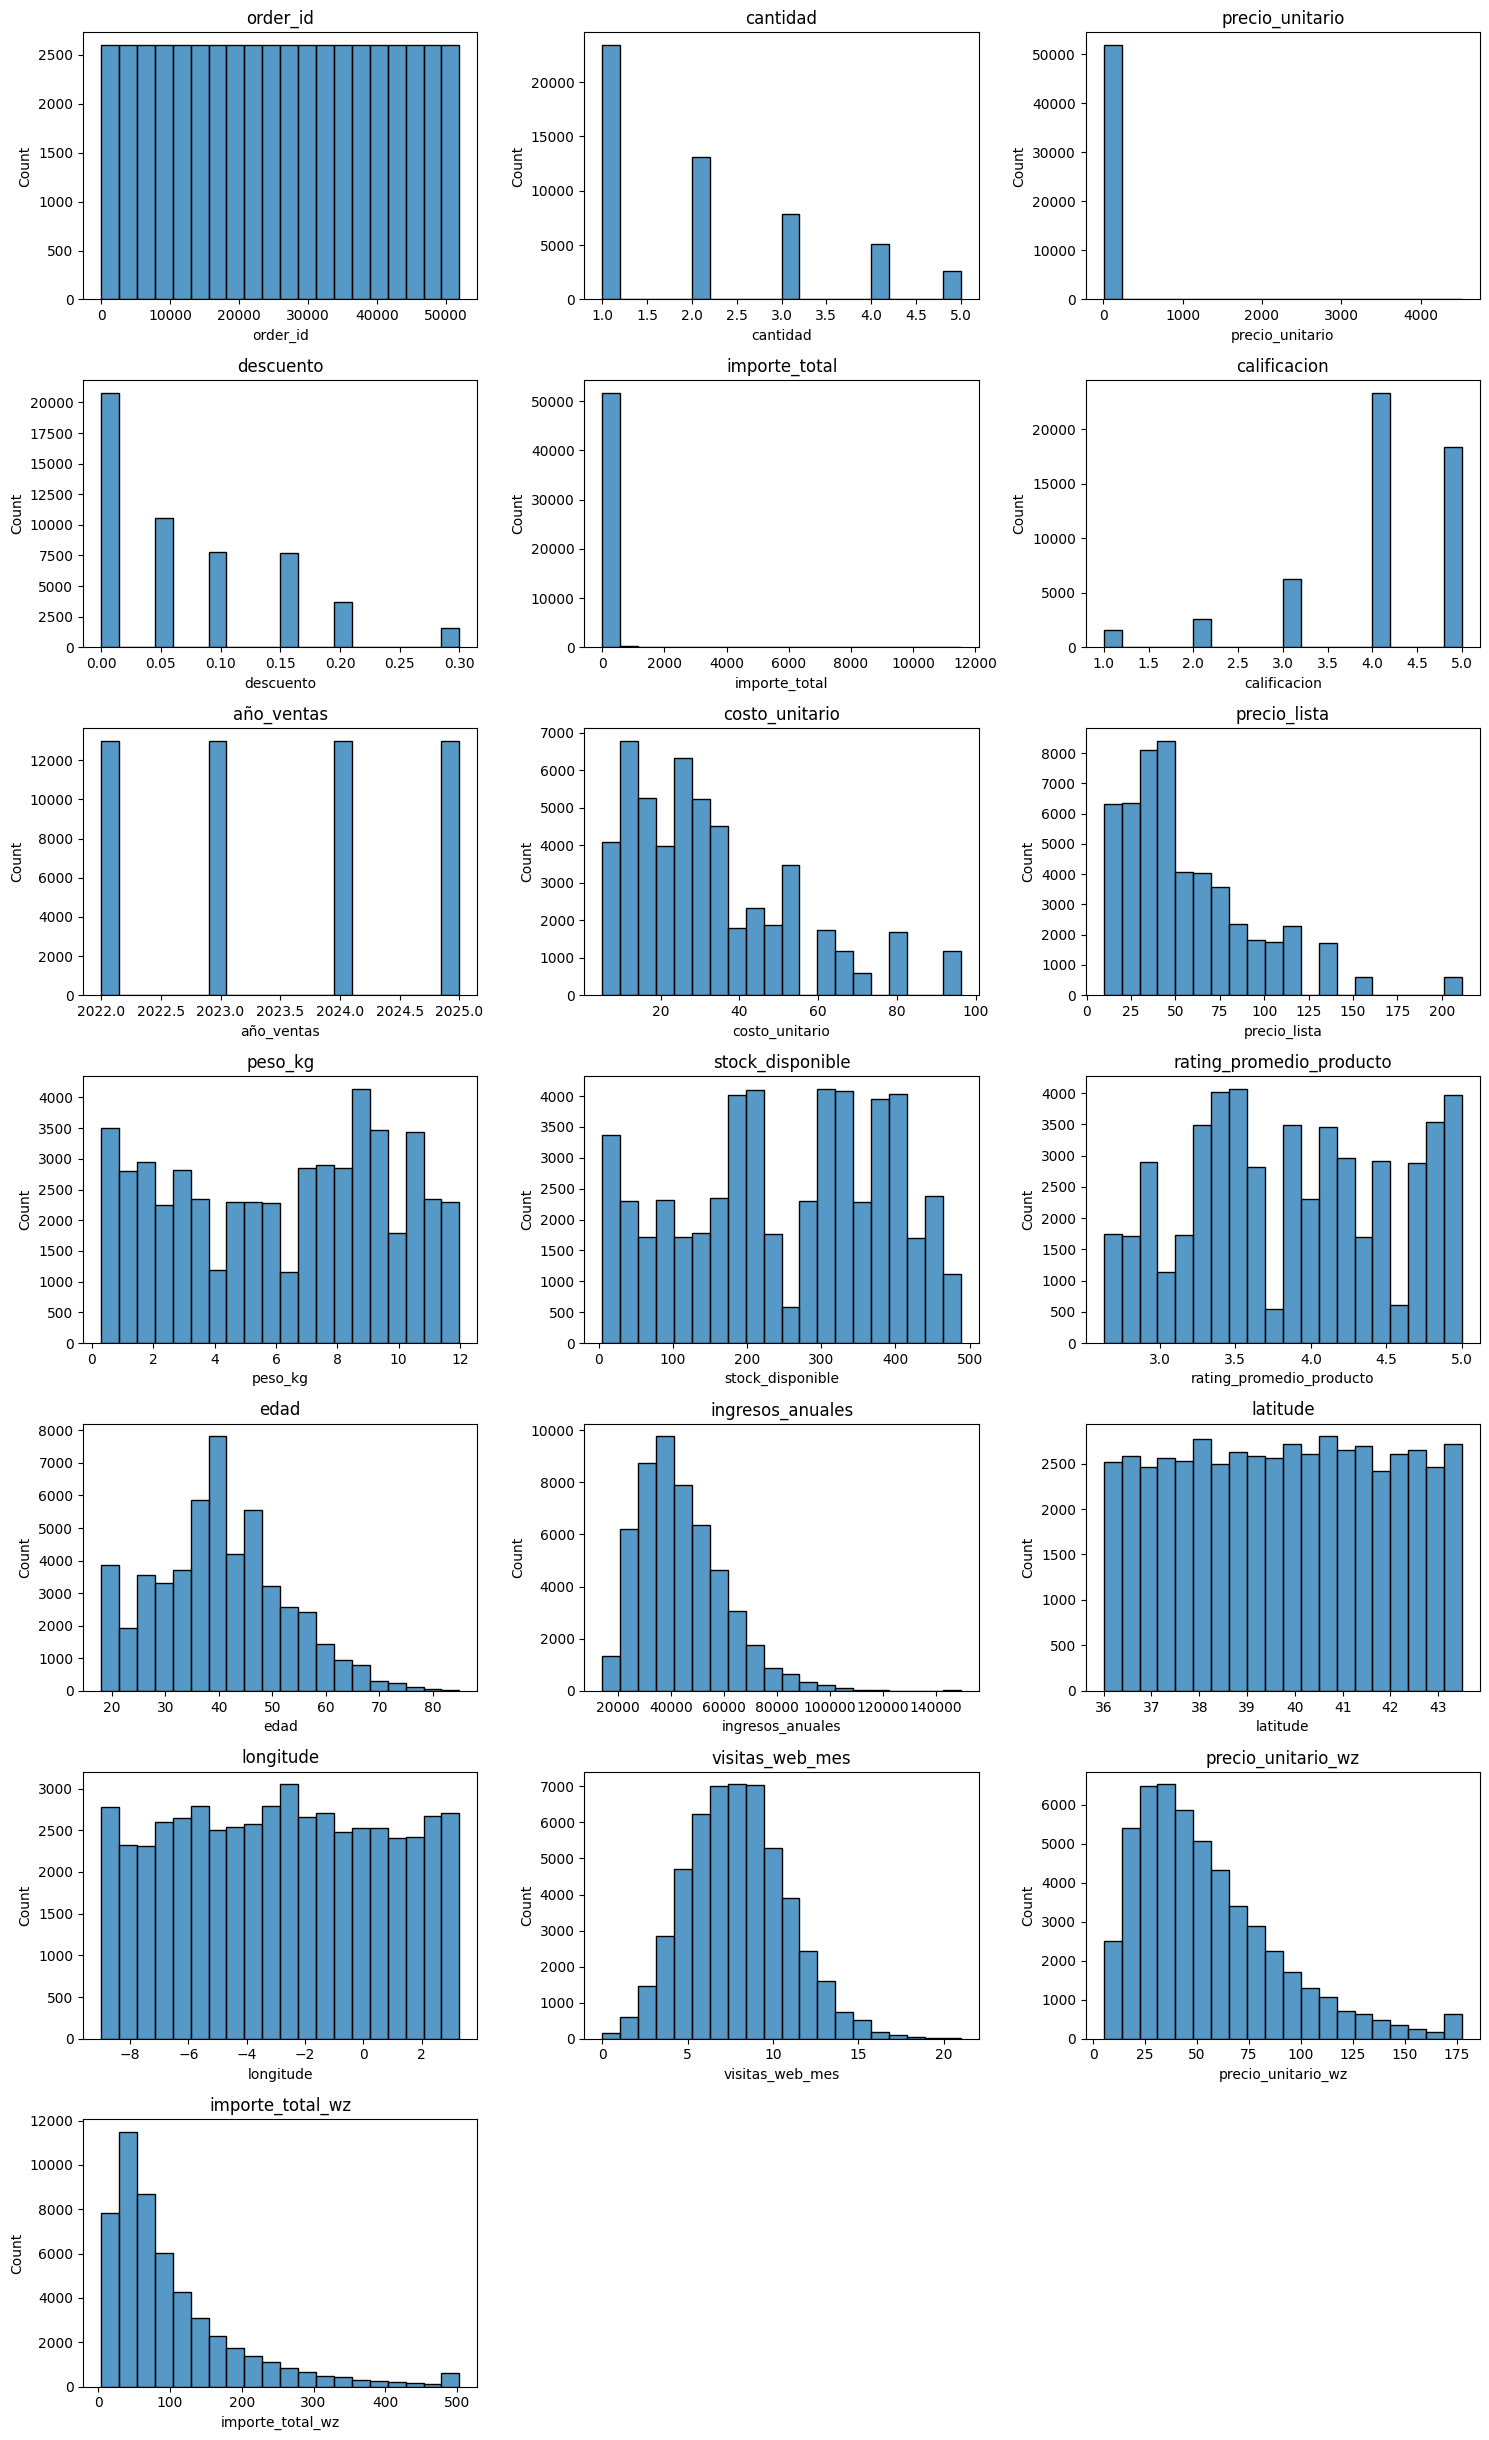


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


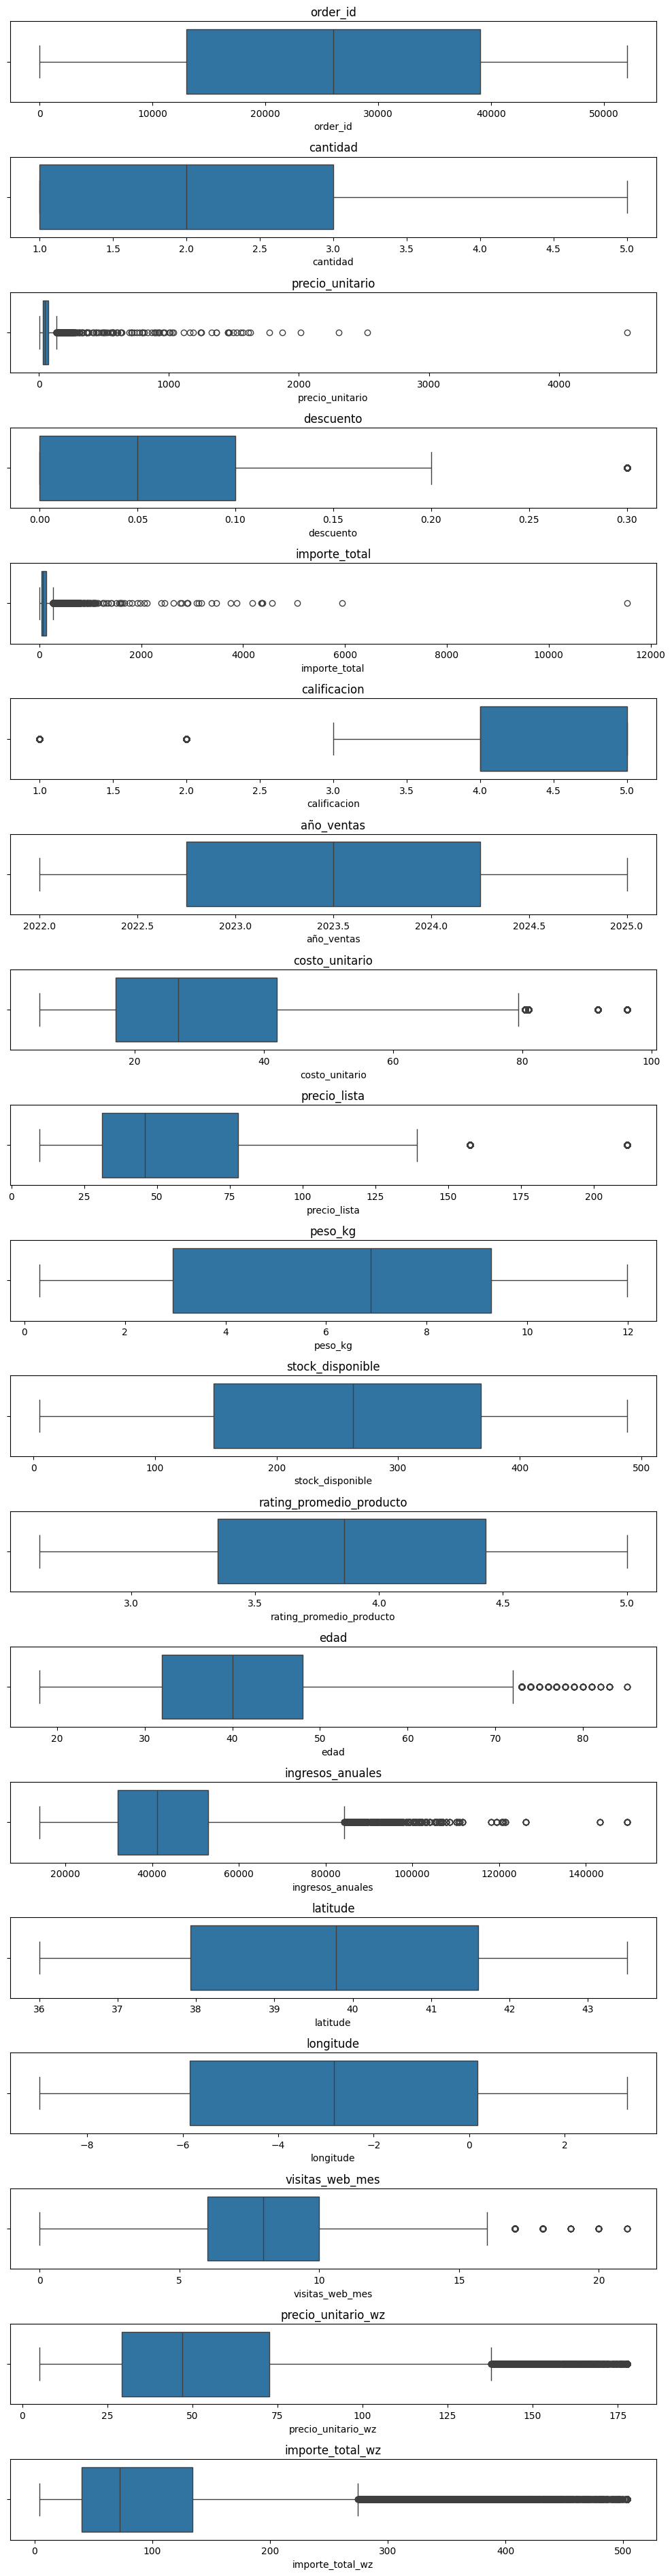

In [7]:
se.eda(df_pedidos)

### Decisión: columnas a excluir en el EDA oficial

A partir de esta exploración, se decide excluir las siguientes columnas 
en la matriz de correlación y en el `eda()` del notebook oficial 
(`03_eda.ipynb`):

- **Identificadores únicos** (`order_id`, `id_cliente`, `product_id`): no 
  son magnitudes comparables.
- **Texto libre** (`nombre_producto`): no aplicable a correlación numérica; 
  se puede valorar estudiar de forma independiente.
- **`latitude`/`longitude`**: no tienen interpretación de negocio directa.
- **`precio_unitario` e `importe_total`**: se excluyen por redundancia, ya 
  que sus versiones winsorizadas (`precio_unitario_wz`, `importe_total_wz`) 
  ya están representadas, evitando duplicar la misma información dos veces.

Esta lista (`cols_excluir`) se define y justifica formalmente al inicio de 
`03_eda.ipynb`, y se reutiliza en `eda()` y `matriz_correlacion()`.

In [8]:
sa.clasificar_columnas(df_pedidos)

,columna,dtype,n_unicos,sugerencia,motivo
0,envio_gratis,str,2,col_control,Categórica con 2 valores únicos: rango razonable para agrupar
1,devuelto,str,2,col_control,Categórica con 2 valores únicos: rango razonable para agrupar
2,tiene_hijos,str,2,col_control,Categórica con 2 valores únicos: rango razonable para agrupar
3,adolescentes_en_casa,str,2,col_control,Categórica con 2 valores únicos: rango razonable para agrupar
4,canal,str,4,col_control,Categórica con 4 valores únicos: rango razonable para agrupar
5,proveedor,str,4,col_control,Categórica con 4 valores únicos: rango razonable para agrupar
6,estado_civil,str,4,col_control,Categórica con 4 valores únicos: rango razonable para agrupar
7,region,str,4,col_control,Categórica con 4 valores únicos: rango razonable para agrupar
8,segmento_cliente,str,4,col_control,Categórica con 4 valores únicos: rango razonable para agrupar
9,categoria_producto,str,5,col_control,Categórica con 5 valores únicos: rango razonable para agrupar


In [13]:
sa.exploracion_df_abtest(df_pedidos, 'canal')

Los principales estadísticos de las columnas categóricas para el grupo APP MOVIL son


,count,unique,top,freq
id_cliente,15498,6860,d2ed5674-22a6-4d6f-ae29-190d8746916e,10
product_id,15498,90,P0003,215
metodo_pago,15498,6,tarjeta de credito,5464
envio_gratis,15498,2,no,10877
devuelto,15498,2,no,14556
canal,15498,1,app movil,15498
categoria_producto,15498,5,libros,3186
nombre_producto,15498,90,Auriculares Nova Max,215
marca,15498,9,vantia,3228
proveedor,15498,4,norte logistica,4503


Los principales estadísticos de las columnas numéricas para el grupo APP MOVIL son


,count,mean,std,min,25%,50%,75%,max
order_id,15498.0,26011.415796,15012.551533,1.000,12973.5000,25858.5000,38953.50000,51999.0000
cantidad,15498.0,2.052265,1.205847,1.000,1.0000,2.0000,3.00000,5.0000
precio_unitario,15498.0,56.813562,66.220681,5.300,29.0025,46.9300,72.62750,4522.2800
descuento,15498.0,0.070374,0.076393,0.000,0.0000,0.0500,0.10000,0.3000
importe_total,15498.0,108.444541,159.096896,4.220,39.6525,71.7900,135.77000,11531.8200
calificacion,15498.0,4.048200,0.963253,1.000,4.0000,4.0000,5.00000,5.0000
año_ventas,15498.0,2023.495999,1.117717,2022.000,2022.0000,2023.0000,2024.00000,2025.0000
costo_unitario,15498.0,32.351437,20.433357,5.240,17.0000,26.7300,42.03000,96.1500
precio_lista,15498.0,56.853572,37.376008,9.700,31.0700,45.8600,77.93000,211.3600
peso_kg,15498.0,6.209388,3.508707,0.300,2.9500,6.8900,9.28000,11.9800


Los principales estadísticos de las columnas categóricas para el grupo TIENDA FISICA son


...

,count,mean,std,min,25%,50%,75%,max
order_id,5235.0,26341.874499,15172.372724,4.000,13143.500,26721.000,39776.0000,51973.0000
cantidad,5235.0,2.055969,1.207590,1.000,1.000,2.000,3.0000,5.0000
precio_unitario,5235.0,56.375773,57.757345,5.470,29.305,47.080,72.3850,2306.3000
descuento,5235.0,0.068911,0.077919,0.000,0.000,0.050,0.1000,0.3000
importe_total,5235.0,108.098925,143.386904,4.710,40.325,73.790,131.2950,4381.9700
calificacion,5235.0,4.052531,0.964458,1.000,4.000,4.000,5.0000,5.0000
año_ventas,5235.0,2023.533906,1.132823,2022.000,2023.000,2024.000,2025.0000,2025.0000
costo_unitario,5235.0,32.280470,20.478295,5.240,17.000,26.730,42.0300,96.1500
precio_lista,5235.0,56.731629,37.548380,9.700,28.120,45.700,78.7500,211.3600
peso_kg,5235.0,6.166160,3.500078,0.300,2.950,6.490,9.0000,11.9800


Los principales estadísticos de las columnas categóricas para el grupo WEB son


,count,unique,top,freq
id_cliente,20887,7435,cd1c7936-b0af-45b4-9903-37685d990d8f,10
product_id,20887,90,P0016,262
metodo_pago,20887,6,tarjeta de credito,7131
envio_gratis,20887,2,no,14598
devuelto,20887,2,no,19679
canal,20887,1,web,20887
categoria_producto,20887,5,electronica,4301
nombre_producto,20887,90,Camara Norte&Co Basic,262
marca,20887,9,vantia,4370
proveedor,20887,4,norte logistica,6068


Los principales estadísticos de las columnas numéricas para el grupo WEB son


,count,mean,std,min,25%,50%,75%,max
order_id,20887.0,25930.062623,15016.365857,7.000,12920.000,25950.000,38933.000,52000.0000
cantidad,20887.0,2.051707,1.202876,1.000,1.000,2.000,3.000,5.0000
precio_unitario,20887.0,56.387734,51.042031,5.090,29.390,47.290,72.590,2526.9400
descuento,20887.0,0.070623,0.076912,0.000,0.000,0.050,0.150,0.3000
importe_total,20887.0,107.515593,130.072431,4.630,40.230,73.140,133.855,5944.6600
calificacion,20887.0,4.043281,0.969339,1.000,4.000,4.000,5.000,5.0000
año_ventas,20887.0,2023.496098,1.118247,2022.000,2022.000,2023.000,2024.000,2025.0000
costo_unitario,20887.0,32.373078,20.419707,5.240,17.000,26.730,42.030,96.1500
precio_lista,20887.0,56.831757,37.369116,9.700,31.070,45.860,77.930,211.3600
peso_kg,20887.0,6.220871,3.509716,0.300,2.950,6.890,9.280,11.9800


In [14]:
sa.exploracion_df_abtest(df_pedidos, 'segmento_cliente')

Los principales estadísticos de las columnas categóricas para el grupo NUEVO son


,count,unique,top,freq
id_cliente,18344,2824,47087e3e-a67b-4354-9bd8-1ecb5b2a653c,18
product_id,18344,90,P0084,234
metodo_pago,18344,6,tarjeta de credito,6370
envio_gratis,18344,2,no,12784
devuelto,18344,2,no,17296
canal,18344,4,web,7331
categoria_producto,18344,5,libros,3761
nombre_producto,18344,90,Biografia Nova Max,234
marca,18344,9,vantia,3856
proveedor,18344,4,norte logistica,5287


Los principales estadísticos de las columnas numéricas para el grupo NUEVO son


,count,mean,std,min,25%,50%,75%,max
order_id,18344.0,26013.411633,15031.317451,1.000,13066.75000,26036.500,39087.7500,52000.0000
cantidad,18344.0,2.047481,1.211613,1.000,1.00000,2.000,3.0000,5.0000
precio_unitario,18344.0,56.860581,67.632211,5.280,29.34750,46.990,72.2550,4522.2800
descuento,18344.0,0.071135,0.077071,0.000,0.00000,0.050,0.1500,0.3000
importe_total,18344.0,108.572529,160.909899,4.560,39.37000,71.860,133.9625,11531.8200
calificacion,18344.0,4.044047,0.972511,1.000,4.00000,4.000,5.0000,5.0000
año_ventas,18344.0,2023.503598,1.118351,2022.000,2023.00000,2024.000,2025.0000,2025.0000
costo_unitario,18344.0,32.489668,20.516678,5.240,17.00000,26.730,42.0300,96.1500
precio_lista,18344.0,57.082209,37.633294,9.700,31.07000,45.860,77.9300,211.3600
peso_kg,18344.0,6.220658,3.520779,0.300,2.95000,6.890,9.2800,11.9800


Los principales estadísticos de las columnas categóricas para el grupo RECURRENTE son


...

,count,mean,std,min,25%,50%,75%,max
order_id,5292.0,25787.175170,15020.226138,12.000,12827.0000,25721.500,38553.2500,51989.0000
cantidad,5292.0,2.042139,1.185945,1.000,1.0000,2.000,3.0000,5.0000
precio_unitario,5292.0,56.693636,52.819033,5.290,29.2900,47.145,73.6400,1613.4700
descuento,5292.0,0.068915,0.076466,0.000,0.0000,0.050,0.1000,0.3000
importe_total,5292.0,107.577884,130.184480,5.030,41.3025,73.845,133.3325,4363.1200
calificacion,5292.0,4.045351,0.971637,1.000,4.0000,4.000,5.0000,5.0000
año_ventas,5292.0,2023.482993,1.114455,2022.000,2022.0000,2023.000,2024.0000,2025.0000
costo_unitario,5292.0,32.160873,20.500568,5.240,17.0000,26.680,42.0300,96.1500
precio_lista,5292.0,56.474758,37.703163,9.700,28.1200,45.700,77.9300,211.3600
peso_kg,5292.0,6.195629,3.521785,0.300,2.9500,6.890,9.2800,11.9800


Los principales estadísticos de las columnas categóricas para el grupo VIP son


,count,unique,top,freq
id_cliente,7596,1166,dfa29b4e-02c3-4bc8-b327-333bbab375f9,17
product_id,7596,90,P0005,110
metodo_pago,7596,6,tarjeta de credito,2631
envio_gratis,7596,2,no,5351
devuelto,7596,2,no,7143
canal,7596,4,web,3078
categoria_producto,7596,5,electronica,1590
nombre_producto,7596,90,Smartphone Zentra Pro,110
marca,7596,9,vantia,1553
proveedor,7596,4,norte logistica,2187


Los principales estadísticos de las columnas numéricas para el grupo VIP son


,count,mean,std,min,25%,50%,75%,max
order_id,7596.0,25885.249605,14995.533825,32.000,12914.5000,25861.500,38824.7500,51996.0000
cantidad,7596.0,2.068589,1.203641,1.000,1.0000,2.000,3.0000,5.0000
precio_unitario,7596.0,56.300065,47.786799,5.400,29.2025,47.530,73.2425,1458.3900
descuento,7596.0,0.070781,0.077317,0.000,0.0000,0.050,0.1000,0.3000
importe_total,7596.0,108.497620,131.406368,4.620,40.1675,73.280,136.6400,5944.6600
calificacion,7596.0,4.050158,0.966720,1.000,4.0000,4.000,5.0000,5.0000
año_ventas,7596.0,2023.492101,1.116430,2022.000,2022.0000,2023.000,2024.0000,2025.0000
costo_unitario,7596.0,32.734656,20.702880,5.240,17.0000,26.730,43.1500,96.1500
precio_lista,7596.0,57.457278,37.857484,9.700,31.0700,45.860,78.7500,211.3600
peso_kg,7596.0,6.157263,3.506617,0.300,2.9500,6.490,9.0700,11.9800
